In [1]:
# !pip install thetaflow
# !pip install lifelines
# !pip install seaborn

In [2]:
import warnings
import time

import pandas as pd
import numpy as np

import pickle

from matplotlib import pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import lifelines

import os

import tensorflow as tf
import tensorflow_probability as tfp

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

from scipy.stats import norm, t
from scipy.special import gamma

# import thetaflow as thf
import modelnn2 as thf

2026-03-12 03:28:33.066935: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/natan/codes/thetaflow_method_paper/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1773296915.619243   11288 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4459 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5


# The dataset

We will be considering a RNA-sequence count table as input to our neural network. This high dimensional table consists of a $n \times p$ matrix where $n$ is the number of patients and $p$ is the number of genes being studied. Each entry to this table represents the number of times a specific gene appeared in the first tumor cell of a given breast cancer patient up to a variance stabilizing transformation. Because of that transformation, the table we get is properly a continuous data matrix.

With that, considering a neural network, we want to directly map that profile to a Weibull survival time distribution. First of all, we must determine if assuming a proportion of cured individuals is valid or not.

In [3]:
df = pd.read_csv("tcga_brca_count_data.csv")

print("Data dimensions: {}".format(df.shape))
df.head()

Data dimensions: (1095, 28400)


,time,delta,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,...,ENSG00000288600.1,ENSG00000288605.1,ENSG00000288610.1,ENSG00000288611.1,ENSG00000288612.1,ENSG00000288658.1,ENSG00000288663.1,ENSG00000288670.1,ENSG00000288674.1,ENSG00000288675.1
0,652,0,9.245133,4.239226,10.967602,10.516892,8.873467,10.470016,11.633765,10.980448,...,4.491879,3.329248,4.239226,3.860372,5.410214,4.374493,6.286277,8.744951,4.596459,6.031172
1,1246,0,10.227104,5.379705,12.348350,10.081262,9.098446,8.663484,10.390532,12.467644,...,4.391943,4.159634,3.329248,3.813047,6.309173,4.010311,4.801600,7.999294,4.010311,5.977130
2,90,0,10.452988,4.632555,10.931232,10.248459,8.212790,7.841121,11.942521,11.401132,...,4.562350,4.632555,3.329248,4.314772,4.214036,3.329248,4.404864,8.188857,3.329248,5.622152
3,1471,0,10.945809,4.443967,10.951945,10.736046,8.323391,9.022657,11.546810,11.058147,...,4.746706,4.246685,3.983344,3.329248,4.982694,3.329248,5.918013,8.379147,3.983344,6.318026
4,172,1,9.745640,4.619213,11.300463,10.703437,8.719260,7.830435,11.842224,11.969159,...,3.771965,3.329248,3.329248,4.090216,6.007179,5.962599,4.911717,9.553867,4.393633,5.741706


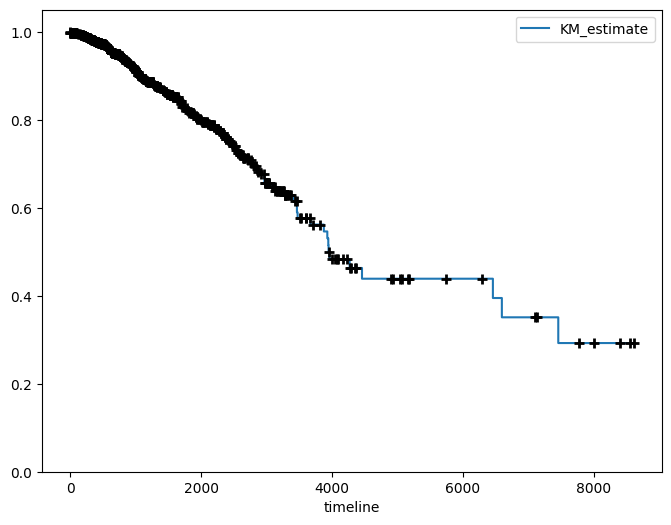

In [4]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df["time"], df["delta"])
km.plot(ax = ax, ci_show = False, show_censors = True, censor_styles={
    'ms': 7,      # marker size
    'marker': '+', # marker shape
    'mew': 2,       # marker edge width
    'markeredgecolor': 'black',
    'zorder': 5
})

ax.set_ylim(0,1.05)

plt.show()

As we can see, data suggests there should exist a fraction of patients that are immune to the event of death, given that for higher times, the Kaplan-Meier curve seems to stabilize at some point greater than zero. In fact, multiple censorships fall in this final value, suggesting a stronger evidence than just random fluctuations would cause data to be like this.

To start our model, let us consider a simple promotion time cure model with a Poisson distributed latent discrete frailty variable. For the base distribution we will be considering a Weibull distribution.

We will also fit a standard Weibull distribution without assuming a cured fraction, so we can compare both models in terms of quantilic residuals for example. For now, we expect that only between both these models, the one that accounts for a cured fraction should be best suited for this particular dataset.

# The models definitions

### Naive Weibull distribution

In [70]:
weibull_parameters = {
    "lam": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 1.0}, # scale
    "rho": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 1.0} # shape
}

def weibull_loglikelihood_loss(model, nn_output, data):
    # Unpack the tuple to include the censoring indicator
    X, y, delta = data
    
    # Extract the strictly positive parameters mapped by the neural network
    lam = model.get_variable("lam", nn_output)
    rho = model.get_variable("rho", nn_output)

    tf.print("lam", lam.shape)
    tf.print("rho", rho.shape)
    tf.print("y", y.shape)
    tf.print("delta", delta.shape)
    
    # Add a tiny epsilon to y to prevent log(0) exploding gradients 
    # if any survival times are exactly 0 in the dataset
    y_safe = y + 1e-8

    # 1. Calculate the log-hazard component (only applied to uncensored data via delta)
    log_hazard = tf.math.log(rho) + (rho - 1.0) * tf.math.log(y_safe) - rho * tf.math.log(lam)
    
    # 2. Calculate the cumulative hazard component (applied to all data)
    cum_hazard = tf.math.pow(y_safe / lam, rho)
    tf.print((delta * log_hazard).shape)
    tf.print("delta * log_hazard", delta * log_hazard)
    tf.print("delta * log_hazard - cum_hazard", delta * log_hazard - cum_hazard)

    tf.print("y problema", y[159])
    tf.print("delta problema", delta[159])
    tf.print(tf.where( tf.math.is_nan(delta * log_hazard - cum_hazard) ))
    
    # 3. Combine to form the simplified log-likelihood
    loglik = tf.reduce_sum( delta * log_hazard - cum_hazard )

    tf.print("loglik", loglik)
    
    # Return the negative log-likelihood for the optimizer to minimize
    return -loglik

def weibull_neural_network(model, seed=None):
    initializer = initializers.GlorotNormal(seed = seed)
    
    # ----- Elastic Net Regularization -----
    # Crucial because p >> n (~60,000 genes vs ~1,000 patients).
    # L1: LASSO Sparsity - feature selection for genes
    # L2: Highly correlated gene clusters, which may lead to multicolinearity problems
    elastic_net = regularizers.L1L2(l1 = 1.0e-4, l2 = 1.0e-4)

    # ----- Compressor layer -----
    # Funnels ~60k normalized gene inputs to a 128 latent space
    model.dense1 = layers.Dense(
        units = 128, 
        activation = "gelu", 
        kernel_initializer = initializer, 
        kernel_regularizer = elastic_net,
        dtype = tf.float32, 
        name = "gene_compressor"
    )
    
    # ----- Dropout Layer -----
    # Prevents the network from memorizing the small number of patients.
    model.dropout = layers.Dropout(rate = 0.5, seed = seed)

    # ----- Hidden dense layer -----
    model.dense2 = layers.Dense(
        units = 32, 
        activation = "gelu", 
        kernel_initializer = initializer, 
        dtype = tf.float32, 
        name = "latent_representation"
    )

    # ----- Output layer (Weibull parameters) -----
    # 2 outputs:
    # - shape parameter rho
    # - scale parameter lambda
    model.output_layer = layers.Dense(
        units = 2, 
        activation = None,
        kernel_initializer = initializers.Zeros(),
        # bias_initializer = initializers.Constant(0.1),
        dtype = tf.float32, 
        name = "weibull_params"
    )
    
def weibull_network_call(model, x_input, training = False):
    # x_input shape: (batch_size, p_genes)
    x = model.dense1(x_input)
    # Dropout is typically only applied during the training phase
    x = model.dropout(x, training = training)
    x = model.dense2(x)
    return model.output_layer(x)

def weibull_network_call_nolast(model, x_input):
    # Pass through the first dense layer
    x = model.dense1(x_input)
    
    # Explicitly turn OFF dropout. 
    # This ensures deterministic feature extraction for the LLLA covariance.
    x = model.dropout(x, training = False) 
    
    # Pass through the final hidden layer
    x = model.dense2(x)
    
    # Return the deterministic latent representation phi(x)
    return x

In [77]:
df.shape

(1095, 28400)

In [76]:
np.where(y < 0)

(array([159]),)

In [71]:
X = df.iloc[:,2:].to_numpy()

y = df.iloc[:,0].to_numpy()/365
delta = df.iloc[:,1].to_numpy()
data = [tf.constant(y, shape = (len(y), 1), dtype = tf.float32), tf.constant(delta, shape = (len(y), 1), dtype = tf.float32)]

In [72]:
weibull_model = thf.ModelNN(weibull_parameters, weibull_loglikelihood_loss,
                            weibull_neural_network, weibull_network_call,
                            weibull_network_call_nolast, input_dim = (None, X.shape[1]), seed = 10)

with tf.GradientTape() as tape:
    nn_output_batch = weibull_model(X, training = True)
    loss_value = weibull_model.loglikelihood_loss(weibull_model, nn_output = nn_output_batch, data = [X] + data)
loss_value

lam TensorShape([1095, 1])
rho TensorShape([1095, 1])
y TensorShape([1095, 1])
delta TensorShape([1095, 1])
TensorShape([1095, 1])
delta * log_hazard [[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]
delta * log_hazard - cum_hazard [[-1.78630137]
 [-3.41369867]
 [-0.246575356]
 ...
 [-2.80821919]
 [-1.57534242]
 [-5.77534246]]
y problema [-0.0191780813]
delta problema [0]
[[159 0]]
loglik nan


<tf.Tensor: shape=(), dtype=float32, numpy=nan>

In [ ]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    weibull_model = thf.ModelNN(weibull_parameters, weibull_loglikelihood_loss,
                                weibull_neural_network, weibull_network_call,
                                weibull_network_call_nolast, input_dim = (None, X.shape[1]), seed = 10)
    
    weibull_lam_before_pretrain = weibull_model.predict(X)["lam"].numpy().flatten()
    weibull_rho_before_pretrain = weibull_model.predict(X)["rho"].numpy().flatten()
    
    weibull_model.pre_train_model(X, data,
                                  epochs = 500, shuffle = True,
                                  metrics_update_freq = 50,
                                  validation = False, val_prop = 0.2,
                                  optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                  optimizer_nn = optimizers.RMSprop(learning_rate = 0.001, clipnorm = 1.0),
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = 4096, gradient_accumulation_steps = None,
                                  early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
                                  reduce_lr = True, reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10, reduce_lr_cooldown = 0,
                                  reduce_lr_min_lr = 1e-4,
                                  deterministic = True,
                                  verbose = 1, track_time = True)

    weibull_lam_after_pretrain = weibull_model.predict(X)["lam"].numpy().flatten()
    weibull_rho_after_pretrain = weibull_model.predict(X)["rho"].numpy().flatten()

    weibull_model.train_model(X, data,
                              epochs = 15000, shuffle = True, metrics_update_freq = 50,
                              get_covariances = True,
                              validation = False, val_prop = 0.2,
                              optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                              optimizer_nn = optimizers.RMSprop(learning_rate = 0.001, clipnorm = 1.0),
                              train_batch_size = None, val_batch_size = None,
                              buffer_size = 4096, gradient_accumulation_steps = None,
                              early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
                              reduce_lr = True, reduce_lr_warmup = 10,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10,
                              reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-5,
                              deterministic = True,
                              verbose = 1, print_freq = 50)

    weibull_lam_after_train = weibull_model.predict(X)["lam"].numpy().flatten()
    weibull_rho_after_train = weibull_model.predict(X)["rho"].numpy().flatten()

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 150 / 15000 ]  | Loss:  nan | Param Dist:  -nan | Independent Learning rate:  0.01 | Network Learning rate:  0.001 | Speed:  10  it/s   

### Promotion time cure model with Poisson and Weibull

In [ ]:
promotion_cure_parameters = {
    "theta": {"link": lambda x : tf.math.exp(x), "link_inv": lambda x : tf.math.log(x), "par_type": "nn", "shape": 1, "init": 1.0},
    "lam": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 1.0}, # scale
    "rho": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 1.0} # shape
}

def promotion_cure_loglikelihood_loss(model, nn_output, data):
    X, y, delta = data
    
    theta = model.get_variable("theta", nn_output)
    lam = model.get_variable("lam")
    rho = model.get_variable("rho")

    y_safe = y + 1e-8
    F0 = 1 - tf.math.exp( -(y_safe / lam)**rho )
    log_f0 = tf.math.log(rho) + (rho-1) * tf.math.log(y_safe) - rho * tf.math.log(lam) - (y_safe / lam)**rho
    
    loglik = tf.reduce_sum( delta*( tf.math.log(theta) + log_f0 ) - theta*F0 )
    
    return -loglik

def promotion_cure_neural_network(model, seed=None):
    initializer = initializers.GlorotNormal(seed = seed)
    
    elastic_net = regularizers.L1L2(l1 = 1.0e-4, l2 = 1.0e-4)
    model.dense1 = layers.Dense(
        units = 128, 
        activation = "gelu", 
        kernel_initializer = initializer, 
        kernel_regularizer = elastic_net,
        dtype = tf.float32, 
        name = "gene_compressor"
    )
    model.dropout = layers.Dropout(rate = 0.5, seed = seed)
    model.dense2 = layers.Dense(
        units = 32, 
        activation = "gelu", 
        kernel_initializer = initializer, 
        dtype = tf.float32, 
        name = "latent_representation"
    )
    model.output_layer = layers.Dense(
        units = 3, 
        activation = None,
        kernel_initializer = initializer, 
        dtype = tf.float32, 
        name = "weibull_params"
    )
    
def promotion_cure_network_call(model, x_input, training = False):
    x = model.dense1(x_input)
    x = model.dropout(x, training = training)
    x = model.dense2(x)
    return model.output_layer(x)

def promotion_cure_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    x = model.dropout(x, training = False) 
    x = model.dense2(x)
    return x